# Actual vs Predicted Soil Moisture 
This notebook loads the trained Random Forest model alongside our test data, and runs visualizations for actual vs predicted soil moisture.

In [1]:
%pip install -r ../requirements.txt
%pip install scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load Processed Features
df = pd.read_csv('../data/Processed/Kaveri_Delta_Soil_Moisture.csv')
x = df[['VV', 'VH', 'NDVI', 'VV_VH_ratio', 'NDVI_VV']]
y = df['soil_moisture']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Load Model
model = joblib.load('../models/random_forest_model.pkl')
y_pred = model.predict(X_test)
print("Data and model loaded successfully!")

Data and model loaded successfully!


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 1. Actual vs Predicted Scatter Plot

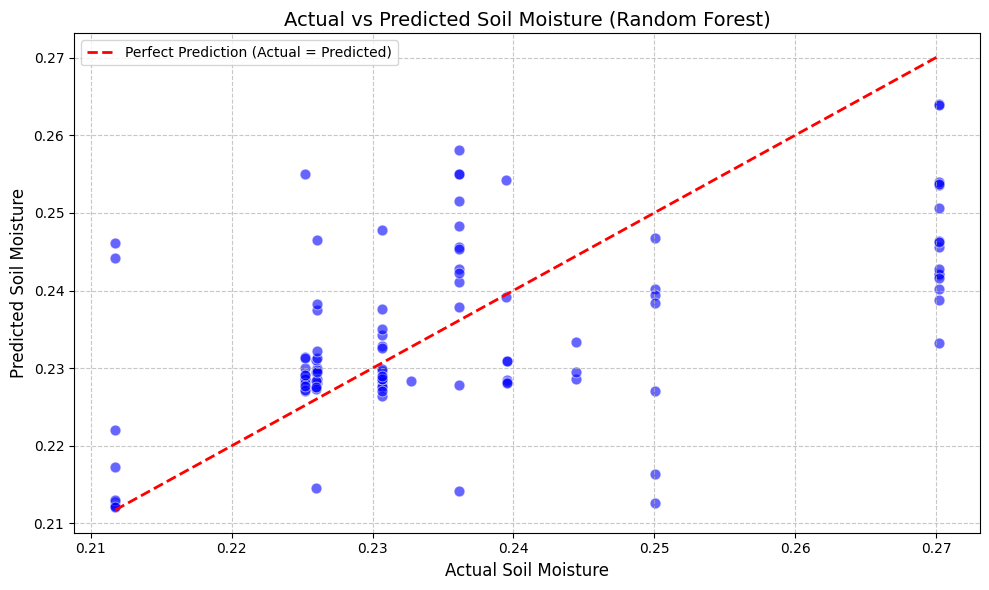

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue', edgecolor='w', s=60)

# Add a reference line for perfect predictions (x=y)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction (Actual = Predicted)')

plt.title('Actual vs Predicted Soil Moisture (Random Forest)', fontsize=14)
plt.xlabel('Actual Soil Moisture', fontsize=12)
plt.ylabel('Predicted Soil Moisture', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Residuals (Errors) Distribution

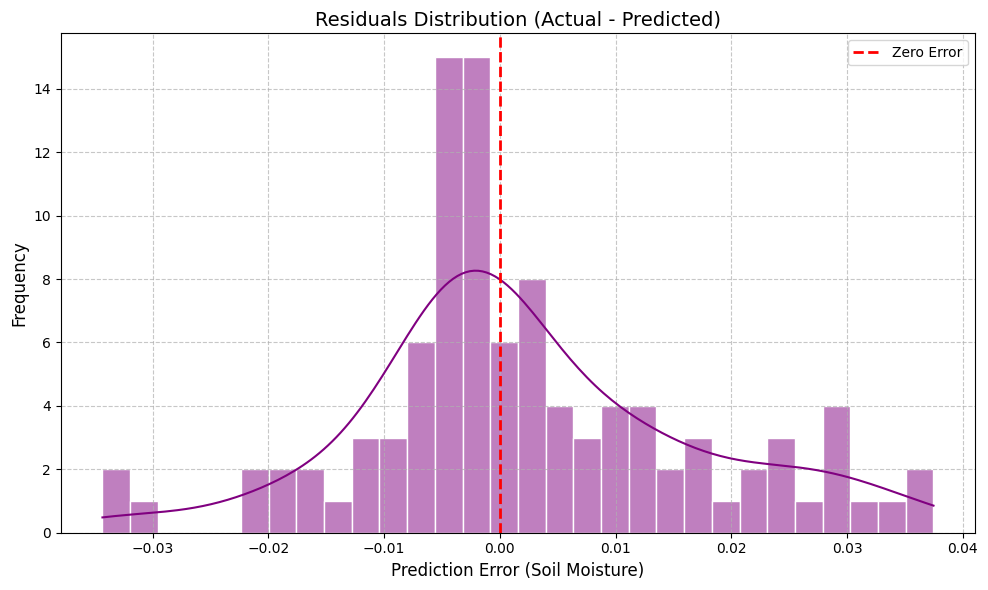

In [6]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color='purple', edgecolor='w')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

plt.title('Residuals Distribution (Actual - Predicted)', fontsize=14)
plt.xlabel('Prediction Error (Soil Moisture)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()